# Data Preprocessing for Supervised Learning

This notebook covers the essential preprocessing steps required before training any supervised learning algorithm. Preprocessing is not optional, it directly determines whether your model learns signal or noise.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import (
    OrdinalEncoder, OneHotEncoder, TargetEncoder,
    StandardScaler, MinMaxScaler, RobustScaler
)
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LinearRegression, LogisticRegression
import scipy.sparse
from sklearn.feature_extraction.text import TfidfVectorizer

np.random.seed(42)
print("All imports successful.")

All imports successful.


---
## 1. Why Preprocessing Matters

Real-world data is messy. Raw data collected from databases, sensors, surveys, or scraping will almost always contain:

- **Missing values**, sensors fail, users skip form fields, database joins drop rows
- **Categorical variables**, text labels that algorithms cannot interpret as numbers
- **Different scales**, one feature ranges from 0 to 1, another from 0 to 1,000,000
- **Outliers**, extreme values that skew learned parameters
- **Datetime columns**, raw timestamps carry no signal until decomposed
- **Sparse, high-dimensional data**, text or one-hot encoded data with mostly zeros

Every algorithm in this supervised learning section requires clean, numeric, appropriately scaled input. Feeding raw data directly into a model typically produces poor or broken results:

- Linear and logistic regression assume features are on comparable scales
- KNN computes Euclidean distances, so unscaled features distort neighborhoods
- SVMs maximize a margin in feature space, so scale matters enormously
- Most sklearn estimators will raise an error if any NaN values remain

Decision trees and random forests are the main exceptions, they are scale-invariant and can handle some missing values natively, but they still benefit from proper encoding and outlier handling.

**Rule of thumb:** Preprocess first, model second. The order cannot be reversed.

---
## 2. Handling Missing Values

In [2]:
# Create a sample DataFrame with missing values
df = pd.DataFrame({
    'age':    [25, np.nan, 35, 40, np.nan, 28, 55, 30, np.nan, 45],
    'income': [50000, 60000, np.nan, 80000, 55000, np.nan, 90000, 72000, 48000, np.nan],
    'score':  [7.5, 8.0, 6.5, np.nan, 7.0, 8.5, np.nan, 6.0, 7.8, 8.2],
    'color':  ['red', 'blue', np.nan, 'green', 'red', 'blue', np.nan, 'green', 'red', 'blue']
})

print("Sample DataFrame:")
print(df)
print()
print("Missing value counts:")
print(df.isnull().sum())
print()
print("Percentage missing:")
print((df.isnull().sum() / len(df) * 100).round(1).astype(str) + '%')

Sample DataFrame:
    age   income  score  color
0  25.0  50000.0    7.5    red
1   NaN  60000.0    8.0   blue
2  35.0      NaN    6.5    NaN
3  40.0  80000.0    NaN  green
4   NaN  55000.0    7.0    red
5  28.0      NaN    8.5   blue
6  55.0  90000.0    NaN    NaN
7  30.0  72000.0    6.0  green
8   NaN  48000.0    7.8    red
9  45.0      NaN    8.2   blue

Missing value counts:
age       3
income    3
score     2
color     2
dtype: int64

Percentage missing:
age       30.0%
income    30.0%
score     20.0%
color     20.0%
dtype: object


In [3]:
# SimpleImputer, numeric columns
numeric_cols = ['age', 'income', 'score']

for strategy in ['mean', 'median']:
    imputer = SimpleImputer(strategy=strategy)
    result = imputer.fit_transform(df[numeric_cols])
    result_df = pd.DataFrame(result, columns=numeric_cols)
    print(f"SimpleImputer(strategy='{strategy}'), imputed statistics:")
    print(f"  age imputed with: {imputer.statistics_[0]:.2f}")
    print(f"  income imputed with: {imputer.statistics_[1]:.2f}")
    print(f"  score imputed with: {imputer.statistics_[2]:.2f}")
    print()

SimpleImputer(strategy='mean'), imputed statistics:
  age imputed with: 36.86
  income imputed with: 65000.00
  score imputed with: 7.44

SimpleImputer(strategy='median'), imputed statistics:
  age imputed with: 35.00
  income imputed with: 60000.00
  score imputed with: 7.65



In [4]:
# SimpleImputer, categorical column (most_frequent)
cat_imputer = SimpleImputer(strategy='most_frequent')
color_imputed = cat_imputer.fit_transform(df[['color']])

print("Categorical imputation (most_frequent):")
print(f"  Most frequent value: '{cat_imputer.statistics_[0]}'")
print(f"  Original color column: {df['color'].tolist()}")
print(f"  Imputed color column: {color_imputed.flatten().tolist()}")

Categorical imputation (most_frequent):
  Most frequent value: 'blue'
  Original color column: ['red', 'blue', nan, 'green', 'red', 'blue', nan, 'green', 'red', 'blue']
  Imputed color column: ['red', 'blue', 'blue', 'green', 'red', 'blue', 'blue', 'green', 'red', 'blue']


In [5]:
# KNNImputer, uses k nearest neighbors to estimate missing values
# Better than simple statistics when features are correlated

knn_imputer = KNNImputer(n_neighbors=3)
knn_result = knn_imputer.fit_transform(df[numeric_cols])
knn_df = pd.DataFrame(knn_result, columns=numeric_cols)

print("KNNImputer(n_neighbors=3) result:")
print(knn_df.round(2))
print()
print("KNN imputation fills each missing value using the weighted average")
print("of the k most similar rows, capturing feature correlations.")

KNNImputer(n_neighbors=3) result:
    age    income  score
0  25.0  50000.00   7.50
1  36.0  60000.00   8.00
2  35.0  54333.33   6.50
3  40.0  80000.00   7.73
4  36.0  55000.00   7.00
5  28.0  54333.33   8.50
6  55.0  90000.00   7.73
7  30.0  72000.00   6.00
8  36.0  48000.00   7.80
9  45.0  54333.33   8.20

KNN imputation fills each missing value using the weighted average
of the k most similar rows, capturing feature correlations.


In [6]:
# IterativeImputer (MICE, Multiple Imputation by Chained Equations)
# Models each feature with missing values as a function of all others
# Iterates until convergence, most accurate but slowest

iter_imputer = IterativeImputer(max_iter=10, random_state=42)
iter_result = iter_imputer.fit_transform(df[numeric_cols])
iter_df = pd.DataFrame(iter_result, columns=numeric_cols)

print("IterativeImputer (MICE) result:")
print(iter_df.round(2))
print()
print("MICE models each feature as a regression on all others,")
print("cycling through until estimates stabilize.")

IterativeImputer (MICE) result:
     age    income  score
0  25.00  50000.00   7.50
1  28.73  60000.00   8.00
2  35.00  69439.20   6.50
3  40.00  80000.00   7.12
4  25.18  55000.00   7.00
5  28.00  58629.33   8.50
6  55.00  90000.00   6.95
7  30.00  72000.00   6.00
8  20.20  48000.00   7.80
9  45.00  79979.15   8.20

MICE models each feature as a regression on all others,
cycling through until estimates stabilize.


In [7]:
# Compare all three imputers on breast cancer dataset with injected missingness
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Inject 20% missing values randomly
rng = np.random.RandomState(42)
X_missing = X.copy().astype(float)
mask = rng.rand(*X_missing.shape) < 0.20
X_missing[mask] = np.nan

print(f"Total values: {X_missing.size}")
print(f"Missing values injected: {mask.sum()} ({mask.mean()*100:.1f}%)")
print()

imputers = {
    'SimpleImputer (mean)': SimpleImputer(strategy='mean'),
    'KNNImputer (k=5)': KNNImputer(n_neighbors=5),
    'IterativeImputer': IterativeImputer(max_iter=5, random_state=42)
}

from sklearn.pipeline import Pipeline

print("Cross-validated accuracy (5-fold) with LogisticRegression:")
print("-" * 50)

for name, imputer in imputers.items():
    pipe = Pipeline([
        ('imputer', imputer),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000))
    ])
    scores = cross_val_score(pipe, X_missing, y, cv=5, scoring='accuracy')
    print(f"{name:<28}: {scores.mean():.4f} +/- {scores.std():.4f}")

Total values: 17070
Missing values injected: 3455 (20.2%)

Cross-validated accuracy (5-fold) with LogisticRegression:
--------------------------------------------------


SimpleImputer (mean)        : 0.9631 +/- 0.0129


KNNImputer (k=5)            : 0.9596 +/- 0.0143


IterativeImputer            : 0.9684 +/- 0.0089


---
## 3. Encoding Categorical Variables

In [8]:
# Sample DataFrame with categorical columns
cat_df = pd.DataFrame({
    'color':  ['red', 'green', 'blue', 'red', 'green', 'blue', 'red', 'green'],
    'size':   ['small', 'medium', 'large', 'medium', 'small', 'large', 'medium', 'small'],
    'rating': ['low', 'medium', 'high', 'low', 'high', 'medium', 'high', 'low'],
    'target': [1, 0, 1, 0, 1, 1, 0, 0]
})

print(cat_df)
print()
print("Unique values per column:")
for col in cat_df.columns:
    print(f"  {col}: {cat_df[col].unique().tolist()}")

   color    size  rating  target
0    red   small     low       1
1  green  medium  medium       0
2   blue   large    high       1
3    red  medium     low       0
4  green   small    high       1
5   blue   large  medium       1
6    red  medium    high       0
7  green   small     low       0

Unique values per column:
  color: ['red', 'green', 'blue']
  size: ['small', 'medium', 'large']
  rating: ['low', 'medium', 'high']
  target: [1, 0]


In [9]:
# OrdinalEncoder, for ordered categories
# size has a natural order: small < medium < large
# rating has a natural order: low < medium < high

ordinal_enc = OrdinalEncoder(
    categories=[
        ['small', 'medium', 'large'],  # size order
        ['low', 'medium', 'high']       # rating order
    ]
)

encoded_ordered = ordinal_enc.fit_transform(cat_df[['size', 'rating']])

print("OrdinalEncoder result (preserves order):")
result_df = pd.DataFrame(encoded_ordered, columns=['size_enc', 'rating_enc'])
print(pd.concat([cat_df[['size', 'rating']], result_df], axis=1))
print()
print("Learned categories:", ordinal_enc.categories_)

OrdinalEncoder result (preserves order):
     size  rating  size_enc  rating_enc
0   small     low       0.0         0.0
1  medium  medium       1.0         1.0
2   large    high       2.0         2.0
3  medium     low       1.0         0.0
4   small    high       0.0         2.0
5   large  medium       2.0         1.0
6  medium    high       1.0         2.0
7   small     low       0.0         0.0

Learned categories: [array(['small', 'medium', 'large'], dtype=object), array(['low', 'medium', 'high'], dtype=object)]


In [10]:
# OneHotEncoder, for unordered categories (no inherent ordering)
# color has no ordering: red is not > green

ohe = OneHotEncoder(sparse_output=False)
color_encoded = ohe.fit_transform(cat_df[['color']])

ohe_df = pd.DataFrame(color_encoded, columns=ohe.get_feature_names_out(['color']))
print("OneHotEncoder result:")
print(pd.concat([cat_df[['color']], ohe_df], axis=1))
print()

# pandas get_dummies comparison
print("Equivalent with pd.get_dummies:")
dummies = pd.get_dummies(cat_df['color'], prefix='color')
print(dummies)
print()
print("Key difference: OneHotEncoder is part of sklearn Pipelines and")
print("can be fit on train data and applied to test data separately.")
print("get_dummies operates on the full DataFrame and can cause train/test mismatch.")

OneHotEncoder result:
   color  color_blue  color_green  color_red
0    red         0.0          0.0        1.0
1  green         0.0          1.0        0.0
2   blue         1.0          0.0        0.0
3    red         0.0          0.0        1.0
4  green         0.0          1.0        0.0
5   blue         1.0          0.0        0.0
6    red         0.0          0.0        1.0
7  green         0.0          1.0        0.0

Equivalent with pd.get_dummies:
   color_blue  color_green  color_red
0       False        False       True
1       False         True      False
2        True        False      False
3       False        False       True
4       False         True      False
5        True        False      False
6       False        False       True
7       False         True      False

Key difference: OneHotEncoder is part of sklearn Pipelines and
can be fit on train data and applied to test data separately.
get_dummies operates on the full DataFrame and can cause train/test mism

In [11]:
# TargetEncoder, for high-cardinality categoricals
# Replaces each category with a smoothed estimate of the target mean

target_enc = TargetEncoder(smooth='auto', cv=2)
color_target_encoded = target_enc.fit_transform(
    cat_df[['color']], cat_df['target']
)

print("TargetEncoder result for 'color':")
te_df = pd.DataFrame({'color': cat_df['color'],
                      'color_target_enc': color_target_encoded.flatten(),
                      'target': cat_df['target']})
print(te_df)
print()
print("TargetEncoder why it beats one-hot for 100+ categories:")
print("  - One-hot creates N binary columns for N categories, 200 categories = 200 columns")
print("  - Each sparse column has very few 1s; the model cannot learn from rare categories")
print("  - TargetEncoder produces exactly 1 column regardless of cardinality")
print("  - The smoothing parameter prevents overfitting on rare categories")
print("  - Tree models can split on 1 numeric column efficiently")

TargetEncoder result for 'color':
   color  color_target_enc  target
0    red               0.0       1
1  green               0.0       0
2   blue               0.5       1
3    red               0.5       0
4  green               0.0       1
5   blue               0.5       1
6    red               0.0       0
7  green               0.5       0

TargetEncoder why it beats one-hot for 100+ categories:
  - One-hot creates N binary columns for N categories, 200 categories = 200 columns
  - Each sparse column has very few 1s; the model cannot learn from rare categories
  - TargetEncoder produces exactly 1 column regardless of cardinality
  - The smoothing parameter prevents overfitting on rare categories
  - Tree models can split on 1 numeric column efficiently


In [12]:
# High cardinality problem demonstration
n_samples = 1000
n_unique = 200

high_card_df = pd.DataFrame({
    'product_id': [f'product_{i % n_unique}' for i in range(n_samples)],
    'price': np.random.uniform(10, 500, n_samples),
    'target': np.random.randint(0, 2, n_samples)
})

print(f"Original dataset shape: {high_card_df.shape}")
print(f"Unique product_id values: {high_card_df['product_id'].nunique()}")
print()

# One-hot explodes the feature space
ohe_expanded = pd.get_dummies(high_card_df['product_id'])
one_hot_shape = (high_card_df.shape[0], ohe_expanded.shape[1] + 1)  # +1 for price
print(f"After one-hot encoding product_id: {one_hot_shape} columns")
print(f"Feature space multiplied by {one_hot_shape[1] / 2:.0f}x")
print()
print(f"After TargetEncoder: (1000, 2) columns, no explosion")
print()
print("With 200 one-hot columns:")
print("  - Most are near-zero (each product appears only ~5 times)")
print("  - Curse of dimensionality: models need exponentially more data")
print("  - Training is slower, memory usage is much higher")

Original dataset shape: (1000, 3)
Unique product_id values: 200

After one-hot encoding product_id: (1000, 201) columns
Feature space multiplied by 100x

After TargetEncoder: (1000, 2) columns, no explosion

With 200 one-hot columns:
  - Most are near-zero (each product appears only ~5 times)
  - Curse of dimensionality: models need exponentially more data
  - Training is slower, memory usage is much higher


---
## 4. Feature Scaling: Which Scaler to Use

In [13]:
# Create a dataset with outliers and very different scales
rng = np.random.RandomState(42)
n = 200

# Feature 1: age in years, with one extreme outlier
age = rng.normal(35, 10, n)
age[0] = 300  # extreme outlier

# Feature 2: salary in dollars, much larger scale
salary = rng.normal(60000, 15000, n)
salary[1] = 5000000  # extreme outlier

X_raw = np.column_stack([age, salary])

print("Raw feature statistics:")
print(f"  age   , min: {age.min():.1f}, max: {age.max():.1f}, mean: {age.mean():.1f}, std: {age.std():.1f}")
print(f"  salary, min: {salary.min():.0f}, max: {salary.max():.0f}, mean: {salary.mean():.0f}, std: {salary.std():.0f}")

Raw feature statistics:
  age   , min: 8.8, max: 300.0, mean: 35.9, std: 20.9
  salary, min: 11381, max: 5000000, mean: 85946, std: 348661


In [14]:
# Apply all three scalers
ss = StandardScaler()
mm = MinMaxScaler()
rs = RobustScaler()

X_standard = ss.fit_transform(X_raw)
X_minmax   = mm.fit_transform(X_raw)
X_robust   = rs.fit_transform(X_raw)

print("StandardScaler (subtract mean, divide by std):")
print(f"  age   , mean: {X_standard[:,0].mean():.4f}, std: {X_standard[:,0].std():.4f}")
print(f"  salary, mean: {X_standard[:,1].mean():.4f}, std: {X_standard[:,1].std():.4f}")
print()
print("MinMaxScaler (scale to [0, 1]):")
print(f"  age   , min: {X_minmax[:,0].min():.4f}, max: {X_minmax[:,0].max():.4f}")
print(f"  salary, min: {X_minmax[:,1].min():.4f}, max: {X_minmax[:,1].max():.4f}")
print()
print("RobustScaler (uses median and IQR):")
print(f"  age   , median: {np.median(X_robust[:,0]):.4f}, IQR-normalized std: {X_robust[:,0].std():.4f}")
print(f"  salary, median: {np.median(X_robust[:,1]):.4f}, IQR-normalized std: {X_robust[:,1].std():.4f}")

StandardScaler (subtract mean, divide by std):
  age   , mean: 0.0000, std: 1.0000
  salary, mean: -0.0000, std: 1.0000

MinMaxScaler (scale to [0, 1]):
  age   , min: 0.0000, max: 1.0000
  salary, min: 0.0000, max: 1.0000

RobustScaler (uses median and IQR):
  age   , median: 0.0000, IQR-normalized std: 1.7119
  salary, median: 0.0000, IQR-normalized std: 17.7399


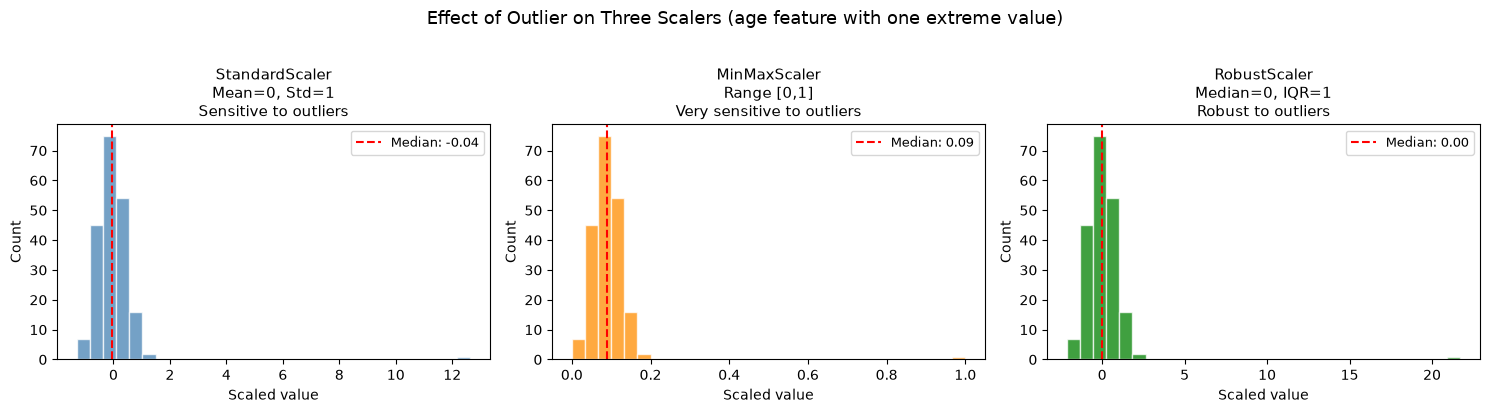

Observation: MinMaxScaler compresses all 'normal' ages into a tiny range
because the single outlier (300) controls the max. RobustScaler is unaffected.


In [15]:
# Plot all three scalers on the 'age' column (which has the outlier)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scaler_data = [
    (X_standard[:, 0], 'StandardScaler', 'steelblue',
     'Mean=0, Std=1\nSensitive to outliers'),
    (X_minmax[:, 0], 'MinMaxScaler', 'darkorange',
     'Range [0,1]\nVery sensitive to outliers'),
    (X_robust[:, 0], 'RobustScaler', 'green',
     'Median=0, IQR=1\nRobust to outliers')
]

for ax, (data, title, color, subtitle) in zip(axes, scaler_data):
    ax.hist(data, bins=30, color=color, alpha=0.75, edgecolor='white')
    ax.set_title(f'{title}\n{subtitle}', fontsize=11)
    ax.set_xlabel('Scaled value')
    ax.set_ylabel('Count')
    ax.axvline(np.median(data), color='red', linestyle='--', linewidth=1.5, label=f'Median: {np.median(data):.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Effect of Outlier on Three Scalers (age feature with one extreme value)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Observation: MinMaxScaler compresses all 'normal' ages into a tiny range")
print("because the single outlier (300) controls the max. RobustScaler is unaffected.")

In [16]:
# Which algorithms need scaling?
print("Algorithms that REQUIRE scaling:")
print("  - Linear Regression: coefficients are on feature scale; unscaled features")
print("    make regularization (L1/L2) apply unequally across features.")
print("  - Logistic Regression: same reason; gradient descent converges much faster.")
print("  - SVM (Support Vector Machines): kernel distances are scale-dependent;")
print("    a feature with large values dominates the margin.")
print("  - KNN: Euclidean distance is computed across all features;")
print("    high-scale features swamp low-scale ones.")
print("  - Neural Networks: activation functions saturate without normalized inputs.")
print("  - PCA: variance-based; a high-scale feature captures all variance.")
print()
print("Algorithms that do NOT need scaling:")
print("  - Decision Trees: split on thresholds, not distances or magnitudes.")
print("  - Random Forests: ensemble of trees; same reasoning.")
print("  - Gradient Boosting (XGBoost, LightGBM): tree-based, scale-invariant.")
print("  - Naive Bayes: works on conditional probabilities, not distances.")

Algorithms that REQUIRE scaling:
  - Linear Regression: coefficients are on feature scale; unscaled features
    make regularization (L1/L2) apply unequally across features.
  - Logistic Regression: same reason; gradient descent converges much faster.
  - SVM (Support Vector Machines): kernel distances are scale-dependent;
    a feature with large values dominates the margin.
  - KNN: Euclidean distance is computed across all features;
    high-scale features swamp low-scale ones.
  - Neural Networks: activation functions saturate without normalized inputs.
  - PCA: variance-based; a high-scale feature captures all variance.

Algorithms that do NOT need scaling:
  - Decision Trees: split on thresholds, not distances or magnitudes.
  - Random Forests: ensemble of trees; same reasoning.
  - Gradient Boosting (XGBoost, LightGBM): tree-based, scale-invariant.
  - Naive Bayes: works on conditional probabilities, not distances.


---
## 5. Outlier Detection and Handling

In [17]:
# Generate dataset with outliers
rng = np.random.RandomState(0)
clean_data = rng.normal(50, 10, 150)
outliers = rng.uniform(150, 200, 10)  # clear outliers
data_with_outliers = np.concatenate([clean_data, outliers])
rng.shuffle(data_with_outliers)

print(f"Dataset: {len(data_with_outliers)} values")
print(f"  True outlier count injected: 10")
print(f"  Min: {data_with_outliers.min():.2f}, Max: {data_with_outliers.max():.2f}")
print(f"  Mean: {data_with_outliers.mean():.2f}, Median: {np.median(data_with_outliers):.2f}")

Dataset: 160 values
  True outlier count injected: 10
  Min: 24.47, Max: 197.22
  Mean: 58.78, Median: 51.93


In [18]:
# IQR method
Q1 = np.percentile(data_with_outliers, 25)
Q3 = np.percentile(data_with_outliers, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outlier_mask = (data_with_outliers < lower_bound) | (data_with_outliers > upper_bound)

print("IQR Method:")
print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"  Lower fence: {lower_bound:.2f}")
print(f"  Upper fence: {upper_bound:.2f}")
print(f"  Outliers detected: {iqr_outlier_mask.sum()} ({iqr_outlier_mask.mean()*100:.1f}%)")

IQR Method:
  Q1=44.07, Q3=59.71, IQR=15.64
  Lower fence: 20.61
  Upper fence: 83.17
  Outliers detected: 10 (6.2%)


In [19]:
# Z-score method
from scipy import stats

z_scores = np.abs(stats.zscore(data_with_outliers))
z_threshold = 3.0
zscore_outlier_mask = z_scores > z_threshold

print("Z-Score Method (threshold = 3):")
print(f"  Mean: {data_with_outliers.mean():.2f}, Std: {data_with_outliers.std():.2f}")
print(f"  Outliers detected: {zscore_outlier_mask.sum()} ({zscore_outlier_mask.mean()*100:.1f}%)")
print()
print("Comparison:")
print(f"  IQR method flagged:     {iqr_outlier_mask.sum()} outliers")
print(f"  Z-score method flagged: {zscore_outlier_mask.sum()} outliers")
print()
print("IQR is more robust because Q1/Q3 are resistant to extreme values.")
print("Z-score uses the mean and std which are themselves skewed by outliers.")

Z-Score Method (threshold = 3):
  Mean: 58.78, Std: 30.97
  Outliers detected: 10 (6.2%)

Comparison:
  IQR method flagged:     10 outliers
  Z-score method flagged: 10 outliers

IQR is more robust because Q1/Q3 are resistant to extreme values.
Z-score uses the mean and std which are themselves skewed by outliers.


In [20]:
# Capping (Winsorizing) with np.clip
# Instead of removing outliers, clip them to the fence values
data_clipped = np.clip(data_with_outliers, lower_bound, upper_bound)

print("Winsorizing (capping at IQR fences) with np.clip:")
print(f"  Before clipping, Max: {data_with_outliers.max():.2f}, Mean: {data_with_outliers.mean():.2f}")
print(f"  After clipping , Max: {data_clipped.max():.2f}, Mean: {data_clipped.mean():.2f}")
print()
print("Advantages of capping over removal:")
print("  - Preserves all rows (no data loss)")
print("  - Prevents extreme values from dominating")
print("  - Keeps the original distribution shape for non-outlier values")
print("  - Required when rows cannot be dropped (e.g., test set in production)")

Winsorizing (capping at IQR fences) with np.clip:
  Before clipping, Max: 197.22, Mean: 58.78
  After clipping , Max: 83.17, Mean: 53.25

Advantages of capping over removal:
  - Preserves all rows (no data loss)
  - Prevents extreme values from dominating
  - Keeps the original distribution shape for non-outlier values
  - Required when rows cannot be dropped (e.g., test set in production)


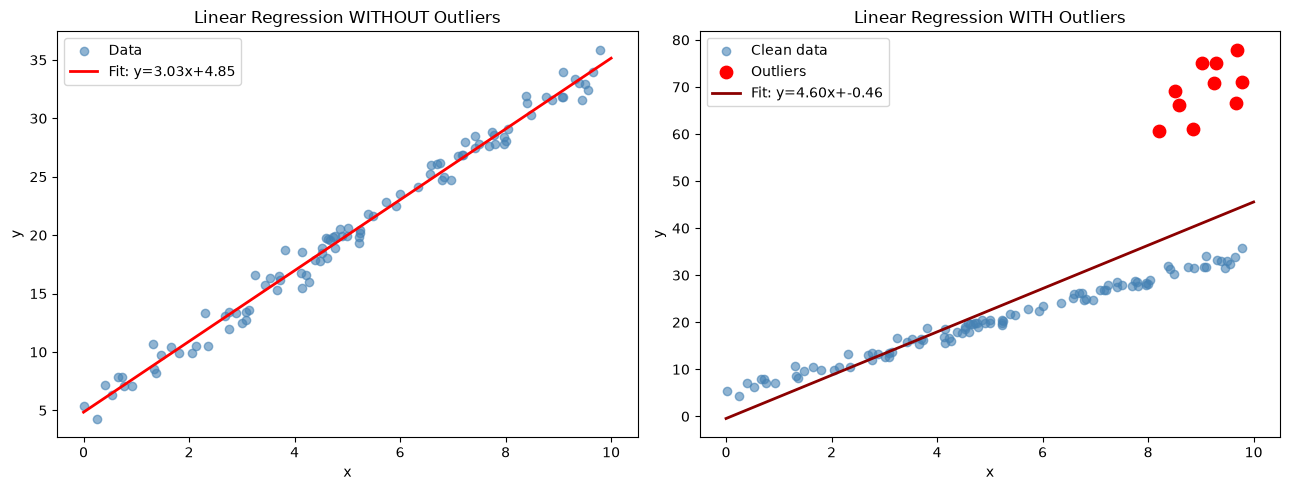

True slope: 3.0
Estimated slope without outliers: 3.030
Estimated slope with outliers:    4.602

Even 10 outliers out of 110 points pull the regression line significantly.


In [21]:
# Effect of outliers on Linear Regression
rng = np.random.RandomState(7)
x_clean = rng.uniform(0, 10, 100)
y_clean = 3 * x_clean + 5 + rng.normal(0, 1, 100)

# Add 10 extreme outliers
x_outlier = np.concatenate([x_clean, rng.uniform(8, 10, 10)])
y_outlier = np.concatenate([y_clean, rng.uniform(60, 80, 10)])

lr_clean   = LinearRegression().fit(x_clean.reshape(-1,1),   y_clean)
lr_outlier = LinearRegression().fit(x_outlier.reshape(-1,1), y_outlier)

x_line = np.linspace(0, 10, 100).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(x_clean, y_clean, alpha=0.6, color='steelblue', label='Data')
axes[0].plot(x_line, lr_clean.predict(x_line), color='red', linewidth=2,
             label=f'Fit: y={lr_clean.coef_[0]:.2f}x+{lr_clean.intercept_:.2f}')
axes[0].set_title('Linear Regression WITHOUT Outliers')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend()

axes[1].scatter(x_clean, y_clean, alpha=0.6, color='steelblue', label='Clean data')
axes[1].scatter(x_outlier[-10:], y_outlier[-10:], color='red', s=80, zorder=5, label='Outliers')
axes[1].plot(x_line, lr_outlier.predict(x_line), color='darkred', linewidth=2,
             label=f'Fit: y={lr_outlier.coef_[0]:.2f}x+{lr_outlier.intercept_:.2f}')
axes[1].set_title('Linear Regression WITH Outliers')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"True slope: 3.0")
print(f"Estimated slope without outliers: {lr_clean.coef_[0]:.3f}")
print(f"Estimated slope with outliers:    {lr_outlier.coef_[0]:.3f}")
print()
print("Even 10 outliers out of 110 points pull the regression line significantly.")

---
## 6. Handling Datetime Features

In [22]:
# Create a DataFrame with a datetime column
rng = np.random.RandomState(0)
n = 500

dates = pd.date_range(start='2022-01-01', periods=n, freq='6h')
dt_df = pd.DataFrame({'timestamp': dates})

# Extract components
dt_df['year']        = dt_df['timestamp'].dt.year
dt_df['month']       = dt_df['timestamp'].dt.month
dt_df['day']         = dt_df['timestamp'].dt.day
dt_df['hour']        = dt_df['timestamp'].dt.hour
dt_df['day_of_week'] = dt_df['timestamp'].dt.dayofweek  # 0=Monday, 6=Sunday
dt_df['is_weekend']  = dt_df['day_of_week'].isin([5, 6]).astype(int)

print("Extracted datetime features:")
print(dt_df.head(12).to_string(index=False))

Extracted datetime features:
          timestamp  year  month  day  hour  day_of_week  is_weekend
2022-01-01 00:00:00  2022      1    1     0            5           1
2022-01-01 06:00:00  2022      1    1     6            5           1
2022-01-01 12:00:00  2022      1    1    12            5           1
2022-01-01 18:00:00  2022      1    1    18            5           1
2022-01-02 00:00:00  2022      1    2     0            6           1
2022-01-02 06:00:00  2022      1    2     6            6           1
2022-01-02 12:00:00  2022      1    2    12            6           1
2022-01-02 18:00:00  2022      1    2    18            6           1
2022-01-03 00:00:00  2022      1    3     0            0           0
2022-01-03 06:00:00  2022      1    3     6            0           0
2022-01-03 12:00:00  2022      1    3    12            0           0
2022-01-03 18:00:00  2022      1    3    18            0           0


In [23]:
# Cyclical encoding for hour and month
# Problem: hour 23 and hour 0 are 23 apart numerically but only 1 hour apart in reality
# Solution: encode as sin/cos so the feature space is circular

dt_df['hour_sin']  = np.sin(2 * np.pi * dt_df['hour']  / 24)
dt_df['hour_cos']  = np.cos(2 * np.pi * dt_df['hour']  / 24)
dt_df['month_sin'] = np.sin(2 * np.pi * dt_df['month'] / 12)
dt_df['month_cos'] = np.cos(2 * np.pi * dt_df['month'] / 12)

print("Cyclical encoding, first few rows:")
print(dt_df[['hour', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos']].head(8).round(3).to_string(index=False))
print()
print("Verification that hour 0 and hour 23 are now close:")
h0  = np.array([np.sin(2*np.pi*0/24),  np.cos(2*np.pi*0/24)])
h23 = np.array([np.sin(2*np.pi*23/24), np.cos(2*np.pi*23/24)])
h12 = np.array([np.sin(2*np.pi*12/24), np.cos(2*np.pi*12/24)])
print(f"  Euclidean distance hour 0  to hour 23: {np.linalg.norm(h0 - h23):.4f}  (close -> correct)")
print(f"  Euclidean distance hour 0  to hour 12: {np.linalg.norm(h0 - h12):.4f}  (far -> correct)")

Cyclical encoding, first few rows:
 hour  hour_sin  hour_cos  month  month_sin  month_cos
    0       0.0       1.0      1        0.5      0.866
    6       1.0       0.0      1        0.5      0.866
   12       0.0      -1.0      1        0.5      0.866
   18      -1.0      -0.0      1        0.5      0.866
    0       0.0       1.0      1        0.5      0.866
    6       1.0       0.0      1        0.5      0.866
   12       0.0      -1.0      1        0.5      0.866
   18      -1.0      -0.0      1        0.5      0.866

Verification that hour 0 and hour 23 are now close:
  Euclidean distance hour 0  to hour 23: 0.2611  (close -> correct)
  Euclidean distance hour 0  to hour 12: 2.0000  (far -> correct)


In [24]:
# Show that cyclical features improve prediction
# Simulate energy usage: peaks at 8am and 6pm, drops at night
dt_df['energy'] = (
    20
    + 10 * np.sin(2 * np.pi * (dt_df['hour'] - 6) / 24)
    + 5  * np.sin(2 * np.pi * dt_df['month'] / 12)
    + dt_df['is_weekend'] * (-3)
    + rng.normal(0, 1.5, n)
)

# Approach 1: use raw hour and month as numeric features
X_raw_dt = dt_df[['hour', 'month', 'is_weekend']].values

# Approach 2: use cyclical encoding
X_cyclic = dt_df[['hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_weekend']].values

y_dt = dt_df['energy'].values

from sklearn.model_selection import cross_val_score

scores_raw    = cross_val_score(LinearRegression(), X_raw_dt, y_dt, cv=5, scoring='r2')
scores_cyclic = cross_val_score(LinearRegression(), X_cyclic,  y_dt, cv=5, scoring='r2')

print("R^2 score, Linear Regression on energy data:")
print(f"  Raw hour/month features:      {scores_raw.mean():.4f} +/- {scores_raw.std():.4f}")
print(f"  Cyclical sin/cos features:    {scores_cyclic.mean():.4f} +/- {scores_cyclic.std():.4f}")
print()
print("Cyclical encoding allows a linear model to capture periodic patterns")
print("that would otherwise require polynomial features or tree splits.")

R^2 score, Linear Regression on energy data:
  Raw hour/month features:      0.3922 +/- 0.0286
  Cyclical sin/cos features:    0.9576 +/- 0.0033

Cyclical encoding allows a linear model to capture periodic patterns
that would otherwise require polynomial features or tree splits.


---
## 7. Sparse Data

In [25]:
# Text dataset -> TF-IDF sparse matrix
corpus = [
    "The quick brown fox jumps over the lazy dog",
    "Machine learning models require numeric input features",
    "Natural language processing converts text into numbers",
    "Sparse matrices save memory when most values are zero",
    "TF-IDF weighs terms by frequency and inverse document frequency",
    "sklearn estimators accept sparse matrices as input directly",
    "The bag of words model ignores word order and grammar",
    "Feature extraction transforms raw data into model-ready format",
    "Preprocessing is the first and often most important step",
    "Clean data leads to better model performance consistently"
]

vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(corpus)

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"  Rows: {X_tfidf.shape[0]} documents")
print(f"  Columns: {X_tfidf.shape[1]} unique terms in vocabulary")
print()
print(f"Is sparse matrix: {scipy.sparse.issparse(X_tfidf)}")
print(f"Sparse matrix type: {type(X_tfidf)}")

TF-IDF matrix shape: (10, 72)
  Rows: 10 documents
  Columns: 72 unique terms in vocabulary

Is sparse matrix: True
Sparse matrix type: <class 'scipy.sparse._csr.csr_matrix'>


In [26]:
# Memory comparison: dense vs sparse
X_dense = X_tfidf.toarray()

total_elements = X_tfidf.shape[0] * X_tfidf.shape[1]
nonzero_elements = X_tfidf.nnz
sparsity = 1 - (nonzero_elements / total_elements)

# Memory in bytes
dense_bytes  = X_dense.nbytes
sparse_bytes = (X_tfidf.data.nbytes
                + X_tfidf.indices.nbytes
                + X_tfidf.indptr.nbytes)

print("Matrix statistics:")
print(f"  Total elements:    {total_elements}")
print(f"  Nonzero elements:  {nonzero_elements}")
print(f"  Sparsity:          {sparsity*100:.1f}% zeros")
print()
print("Memory usage:")
print(f"  Dense  (numpy array):   {dense_bytes:>8} bytes  ({dense_bytes/1024:.2f} KB)")
print(f"  Sparse (CSR matrix):    {sparse_bytes:>8} bytes  ({sparse_bytes/1024:.2f} KB)")
print(f"  Memory ratio:           {dense_bytes / sparse_bytes:.1f}x more memory in dense format")
print()
print("At larger scale (100k docs, 50k vocab): dense = 40 GB, sparse = ~200 MB")

Matrix statistics:
  Total elements:    720
  Nonzero elements:  84
  Sparsity:          88.3% zeros

Memory usage:
  Dense  (numpy array):       5760 bytes  (5.62 KB)
  Sparse (CSR matrix):        1052 bytes  (1.03 KB)
  Memory ratio:           5.5x more memory in dense format

At larger scale (100k docs, 50k vocab): dense = 40 GB, sparse = ~200 MB


In [27]:
# sklearn algorithms accept sparse input directly
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Create labels for demonstration
y_text = np.array([0, 1, 1, 1, 1, 1, 0, 1, 1, 0])

# Train directly on sparse matrix, no .toarray() needed
lr = LogisticRegression(max_iter=1000)
lr.fit(X_tfidf, y_text)  # X_tfidf is sparse

nb = MultinomialNB()
nb.fit(X_tfidf, y_text)  # also accepts sparse

lr_preds = lr.predict(X_tfidf)
nb_preds = nb.predict(X_tfidf)

print("sklearn models trained directly on sparse TF-IDF matrix (no .toarray() call):")
print(f"  LogisticRegression predictions: {lr_preds.tolist()}")
print(f"  MultinomialNB predictions:      {nb_preds.tolist()}")
print(f"  True labels:                    {y_text.tolist()}")
print()
print("Sparse support is critical for text/NLP: converting to dense would")
print("allocate enormous arrays and likely exhaust available RAM.")

sklearn models trained directly on sparse TF-IDF matrix (no .toarray() call):
  LogisticRegression predictions: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  MultinomialNB predictions:      [0, 1, 1, 1, 1, 1, 0, 1, 1, 0]
  True labels:                    [0, 1, 1, 1, 1, 1, 0, 1, 1, 0]

Sparse support is critical for text/NLP: converting to dense would
allocate enormous arrays and likely exhaust available RAM.


---
## 8. Complete Preprocessing Checklist

Before fitting any supervised learning model, run through this checklist in order:

1. **Inspect the data shape and types**, `df.shape`, `df.dtypes`, `df.head()`. Know what you have before touching anything.

2. **Check missing values**, `df.isnull().sum()`. Decide per column: drop rows, drop column, impute with mean/median/mode, KNN, or MICE.

3. **Check class balance**, `y.value_counts()`. Imbalanced classes require stratified splits, resampling, or class-weighted models.

4. **Split before transforming**, Call `train_test_split` FIRST. All subsequent fit/transform steps are fit on train only, then applied to test. This prevents data leakage.

5. **Encode categorical variables**, Use `OrdinalEncoder` for ordered categories, `OneHotEncoder` for unordered with low cardinality, `TargetEncoder` for high-cardinality (100+ unique values).

6. **Handle datetime columns**, Extract year, month, day, hour, day_of_week, is_weekend. Apply sin/cos transformation to cyclic components (hour, month, day_of_week).

7. **Detect and handle outliers**, Use IQR or Z-score to identify outliers. Choose: remove rows, cap with `np.clip`, or use a robust algorithm. For linear models, outlier handling is especially important.

8. **Scale numeric features**, Use `StandardScaler` as the default. Use `RobustScaler` when outliers remain after step 7. Use `MinMaxScaler` only when you need hard [0,1] bounds (e.g., neural network inputs). Skip scaling for tree-based models.

9. **Verify no NaN or Inf values remain**, `np.any(np.isnan(X_train))`, `np.any(np.isinf(X_train))`. These cause silent failures in many estimators.

10. **Check feature distributions**, Plot histograms. Highly skewed numeric features often benefit from log or square-root transformation before scaling.

11. **Wrap all steps in a Pipeline**, Use `sklearn.pipeline.Pipeline` so the same transformations are applied identically at training and inference time, eliminating an entire category of production bugs.

12. **Baseline before feature engineering**, Fit the simplest possible model on your preprocessed data to establish a baseline. Complex feature engineering should only continue if it improves on this baseline.